# Planar 3-Link Robot — Kinematics

This notebook walks through the math behind the [`src/`](../src) implementation:

- **Forward kinematics (FK)**: given joint angles $q\in\mathbb{R}^3$, compute the end-effector pose $(x, y, \theta)$.
- **Jacobian** $J(q) = \partial(x,y,\theta)/\partial q$ via numerical differentiation.
- **Pseudo-inverse** $J^{+}$ via SVD.
- **Inverse kinematics (IK)** via damped Newton iteration on the FK error.

Each section maps an equation to a function in [`src/task.cpp`](../src/task.cpp).

## 1. Robot model

Three revolute joints, three unit-length links ($\ell = 1$). The kinematic chain is:

```
ground ──┤J₀├── link 1 ──┤J₁├── link 2 ──┤J₂├── link 3 ──◆ end-effector
   ▲     q₀              q₁              q₂
fixed
```

So **3 joints ↔ 3 joint angles $(q_0, q_1, q_2) \,\leftrightarrow\, 3$ links.** Joint 0 is fixed to the world at the origin — it doesn't translate, but its angle $q_0$ rotates link 1 around the base. Joints 1 and 2 connect consecutive moving links. (Counting heuristic for any serial revolute chain: $n$ links $\Rightarrow n$ joints, because every link including the first needs a joint connecting it to the body before it.)

**Visual conventions used in every plot below:**

| Marker | What it represents |
|---|---|
| ▲ black triangle on hatched ground | **Joint 0** ($J_0$) — fixed to world, rotates link 1 by $q_0$ |
| ○ open circle | **Joint 1** ($J_1$) — between link 1 and link 2, rotates by $q_1$ |
| ○ open circle | **Joint 2** ($J_2$) — between link 2 and link 3, rotates by $q_2$ |
| ◆ filled diamond | End-effector (tip of link 3 — no joint here) |

That's **4 distinguishable markers with 3 link segments between them**, regardless of the configuration. When an arm "folds" (e.g. link 3 lying on top of link 2), the diamond will sit on top of an open circle — that's the visual signature of a fold.

Joint vector $q = (q_0, q_1, q_2)^\top$, where each $q_i$ is the rotation **at joint $i$ relative to the previous link's frame**. Let $\phi_k = \sum_{i=0}^{k} q_i$ denote the cumulative orientation through joint $k$.

By convention in this codebase the **link offset is $(0, 1)$ in the local (post-rotation) frame** — i.e. each link extends along its own local $+y$-axis. This is why FK looks the way it does.

## 2. Forward kinematics

The world-frame pose of the end effector is obtained by chaining the rotation–translate pairs:

$$T(q) \;=\; R(q_0)\,T_\ell\,R(q_1)\,T_\ell\,R(q_2)\,T_\ell$$

where $R(\alpha)$ is a 2D rotation by $\alpha$ and $T_\ell$ is a translation by $(0, \ell) = (0, 1)$ in the **local** frame.

Carrying out the multiplication, the end-effector position is the vector sum of three local-frame offsets, each rotated into world coordinates by the cumulative orientation up to that joint:

$$
\begin{aligned}
x &= -\sin\phi_0 - \sin\phi_1 - \sin\phi_2 \\
y &= \;\;\;\cos\phi_0 + \cos\phi_1 + \cos\phi_2 \\
\theta &= \phi_2 = q_0 + q_1 + q_2
\end{aligned}
$$

**Sanity check** for $q = (\pi, \pi/2, \pi/2)$:
$\phi_0 = \pi,\;\phi_1 = 3\pi/2,\;\phi_2 = 2\pi$, so
$x = -0 - (-1) - 0 = 1,\; y = -1 + 0 + 1 = 0,\; \theta = 0$. This matches `Kinematics.FK` in [`tests/src/kinematics_tests.cpp`](../tests/src/kinematics_tests.cpp).

### FK in C++

From [`src/task.cpp`](../src/task.cpp) — `forward_kinematics`:

```cpp
trafo2d_t forward_kinematics(vector_t const & q) {
    trafo2d_t link_offset = trafo2d_t::Identity();
    link_offset.translation()(1) = 1.;          // (0, 1) in local frame

    trafo2d_t trafo = trafo2d_t::Identity();    // start at world origin
    for (int j = 0; j < 3; ++j) {
        trafo *= Eigen::Rotation2D<double>(q(j)); // R(q_j)
        trafo  = trafo * link_offset;             // T_ell in current local frame
    }
    return trafo;
}
```

Each loop iteration performs one $R\,T_\ell$ pair, so after three iterations we have the chain $T(q)$ above.

The pose triple $(x, y, \theta)$ is extracted by `transformationMatrixToPose`: $(x, y)$ are the translation, and $\theta = \operatorname{atan2}(R_{1,0}, R_{0,0})$.

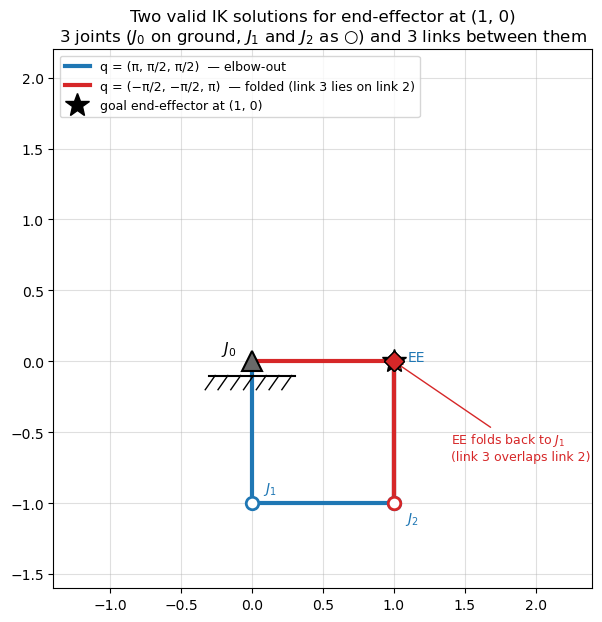

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def forward_kinematics(q, link_length=1.0):
    """Return the 4 joint/EE positions: [J0(=base), J1, J2, EE] (each a 2-vector).
    The 3 line segments between consecutive points are the 3 links."""
    pts = [np.array([0.0, 0.0])]                 # J0 at world origin
    phi = 0.0
    for qi in q:
        phi += qi
        pts.append(pts[-1] + link_length * np.array([-np.sin(phi), np.cos(phi)]))
    return np.array(pts)

def plot_base(ax, base=(0.0, 0.0), size=0.30, label=None):
    """Draw the fixed base anchor (the location of joint J0) with hatched ground.
    If label is given (e.g. '$J_0$'), annotate the anchor with it."""
    x0, y0 = base
    # Triangle = anchor showing the joint is grounded
    ax.plot(x0, y0, marker='^', color='black', markersize=15,
            markerfacecolor='dimgray', markeredgewidth=1.5, zorder=10,
            clip_on=False)
    # Hatched ground line below the anchor
    half = size
    y_ground = y0 - 0.10
    ax.plot([x0 - half, x0 + half], [y_ground, y_ground], 'k-', lw=1.5, zorder=9)
    for t in np.linspace(-half + 0.04, half - 0.02, 7):
        ax.plot([x0 + t, x0 + t - 0.07], [y_ground, y_ground - 0.10],
                'k-', lw=1.0, zorder=9)
    if label is not None:
        ax.annotate(label, (x0, y0), textcoords='offset points',
                    xytext=(-22, 6), fontsize=11, color='black', zorder=11)

def plot_robot(ax, q, color='C0', label=None, alpha=1.0, lw=3.0,
               show_joint_labels=False):
    """Draw a 3-link planar arm.
    Polyline = the 3 links. Open circles at J1, J2. Filled diamond at EE.
    Use plot_base(ax) once per axes to draw the fixed base (J0)."""
    pts = forward_kinematics(q)
    # 3 links as a single polyline (segments visible if no overlap)
    ax.plot(pts[:, 0], pts[:, 1], '-', color=color, lw=lw, alpha=alpha,
            label=label, zorder=2)
    # Intermediate joints J1, J2 — open white-filled circles
    ax.plot(pts[1:3, 0], pts[1:3, 1], 'o', color=color, markersize=9,
            markerfacecolor='white', markeredgewidth=2, alpha=alpha, zorder=3)
    # End-effector — filled diamond
    ax.plot(pts[3, 0], pts[3, 1], 'D', color=color, markersize=10,
            markeredgecolor='black', markeredgewidth=1, alpha=alpha, zorder=4)
    if show_joint_labels:
        for name, pt, off in [('$J_1$', pts[1], (8, 8)),
                              ('$J_2$', pts[2], (8, -14)),
                              ('EE',    pts[3], (10, 0))]:
            ax.annotate(name, pt, textcoords='offset points',
                        xytext=off, fontsize=10, color=color, zorder=11)

# Demo: two valid IK solutions for the same end-effector pose at (1, 0, theta=0).
# Both configurations have 3 joints (J0 at the anchor, J1 and J2 as open circles)
# and 3 links connecting them. The red one happens to fold so link 3 lies on link 2.
fig, ax = plt.subplots(figsize=(7.5, 7))
plot_base(ax, label='$J_0$')
plot_robot(ax, [np.pi, np.pi/2, np.pi/2], color='C0',
           label='q = (π, π/2, π/2)  — elbow-out',
           show_joint_labels=True)
plot_robot(ax, [-np.pi/2, -np.pi/2, np.pi], color='C3',
           label='q = (−π/2, −π/2, π)  — folded (link 3 lies on link 2)')
ax.plot(1, 0, 'k*', markersize=18, label='goal end-effector at (1, 0)')

# Annotate the fold: in the red config the EE coincides with J1
ax.annotate('EE folds back to $J_1$\n(link 3 overlaps link 2)',
            xy=(1, 0), xytext=(1.4, -0.7), fontsize=9, color='C3',
            arrowprops=dict(arrowstyle='->', color='C3', lw=1))

ax.set_aspect('equal'); ax.grid(True, alpha=0.4)
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(-1.4, 2.4); ax.set_ylim(-1.6, 2.2)
ax.set_title('Two valid IK solutions for end-effector at (1, 0)\n'
             '3 joints ($J_0$ on ground, $J_1$ and $J_2$ as ○) and 3 links between them')
plt.show()

## 3. Jacobian

The Jacobian relates joint-velocity to end-effector pose-velocity:

$$J(q) = \frac{\partial (x, y, \theta)}{\partial (q_0, q_1, q_2)} \in \mathbb{R}^{3\times 3}$$

Differentiating the FK above column-by-column (note that $\phi_k$ depends on $q_i$ iff $i \le k$):

$$
J(q) =
\begin{bmatrix}
-\cos\phi_0 - \cos\phi_1 - \cos\phi_2 & -\cos\phi_1 - \cos\phi_2 & -\cos\phi_2 \\
-\sin\phi_0 - \sin\phi_1 - \sin\phi_2 & -\sin\phi_1 - \sin\phi_2 & -\sin\phi_2 \\
1 & 1 & 1
\end{bmatrix}
$$

The lower-triangular structure (each column drops a leading term) reflects the chain rule: $q_2$ only moves the last link; $q_1$ moves links 2 and 3; $q_0$ moves everything.

**Singular configurations.** $\det J = 0$ when joint axes line up — for this robot, when two consecutive cumulative angles satisfy $\phi_i = \phi_{i+1}$ (i.e., the corresponding $q_{i+1} = 0$ or $\pi$). Near a singularity, $J^{+}$ amplifies noise, which is why we damp the step (see §5).

### Jacobian in C++ — numerical differentiation

Rather than coding the analytical Jacobian, the implementation uses **Eigen's finite-difference** module, which calls FK at $q$ and at perturbed points $q + h e_i$ to estimate each column.

From [`src/task.cpp`](../src/task.cpp):

```cpp
Eigen::MatrixXd numericalDifferentiationFK(const Eigen::VectorXd &q) {
    numericalDifferentiationFKFunctor functor;       // wraps FK as 3 -> 3 mapping
    Eigen::NumericalDiff<numericalDifferentiationFKFunctor> numDiff(functor);
    Eigen::MatrixXd fjac(3, 3);
    numDiff.df(q, fjac);                             // central differences
    return fjac;
}
```

Trade-off: numerical differentiation is convenient (no derivation needed, robust to FK changes) but ~3–7× more FK evaluations per Jacobian and slightly less accurate. For this small problem it's fine.

In [2]:
def fk_pose(q):
    """Returns (x, y, theta) for the end effector."""
    pts = forward_kinematics(q)
    x, y = pts[-1]
    return np.array([x, y, np.sum(q)])

def jacobian_analytic(q):
    phi = np.cumsum(q)
    J = np.zeros((3, 3))
    # x and y rows: column j depends on phi_j, phi_{j+1}, ..., phi_{n-1}
    for j in range(3):
        J[0, j] = -np.sum(np.cos(phi[j:]))
        J[1, j] = -np.sum(np.sin(phi[j:]))
        J[2, j] = 1.0
    return J

def jacobian_numeric(q, h=1e-6):
    J = np.zeros((3, 3))
    for j in range(3):
        e = np.zeros(3); e[j] = h
        J[:, j] = (fk_pose(q + e) - fk_pose(q - e)) / (2 * h)
    return J

q_test = np.array([0.4, -0.7, 1.1])
print('analytic =\n', jacobian_analytic(q_test))
print('\nnumeric  =\n', jacobian_numeric(q_test))
print('\nmax abs diff =', np.max(np.abs(jacobian_analytic(q_test) - jacobian_numeric(q_test))))

analytic =
 [[-2.57310419 -1.6520432  -0.69670671]
 [-0.81125423 -0.42183588 -0.71735609]
 [ 1.          1.          1.        ]]

numeric  =
 [[-2.57310419 -1.6520432  -0.69670671]
 [-0.81125423 -0.42183588 -0.71735609]
 [ 1.          1.          1.        ]]

max abs diff = 2.072594318391907e-10


## 4. Pseudo-inverse via SVD

We need to invert $J$ to map a desired pose change $\Delta p$ back to a joint change $\Delta q$. When $J$ is square and well-conditioned this is just $J^{-1}$, but at singularities $J$ becomes rank-deficient and $J^{-1}$ blows up.

The **Moore–Penrose pseudo-inverse** $J^{+}$ is the right generalization. Using the SVD $J = U\,\Sigma\,V^\top$ with singular values $\sigma_i$:

$$J^{+} = V\,\Sigma^{+}\,U^\top, \qquad \Sigma^{+}_{ii} = \begin{cases} 1/\sigma_i & \sigma_i > \tau \\ 0 & \text{otherwise} \end{cases}$$

where $\tau$ is a tolerance. Truncating tiny singular values prevents amplifying noise in degenerate directions.

From [`src/task.cpp`](../src/task.cpp) — `pseudoInverse`:

```cpp
Eigen::JacobiSVD<T> svd(a, flags);
double tolerance = epsilon * std::max(a.cols(), a.rows()) *
                   svd.singularValues().array().abs()(0);
return svd.matrixV() *
       (svd.singularValues().array().abs() > tolerance)
           .select(svd.singularValues().array().inverse(), 0)
           .matrix().asDiagonal() *
       svd.matrixU().adjoint();
```

The threshold $\tau = \epsilon_{\text{mach}} \cdot \max(m, n) \cdot \sigma_{\max}$ is the standard one (it's what NumPy's `pinv` uses by default).

## 5. Inverse kinematics — damped Newton iteration

Given a goal pose $p^*$ and an initial guess $q_0$, we want to find $q$ such that $f(q) = p^*$, where $f$ is the FK. This is a non-linear root-finding problem; we solve it with a damped Newton iteration that uses $J^{+}$ in place of $J^{-1}$.

**Algorithm**

$$
\begin{aligned}
&\textbf{repeat}\ k = 0, 1, \dots:\\
&\quad e_k = p^* - f(q_k)\\
&\quad \textbf{if}\ \|e_k\| < \text{tol}:\ \textbf{break}\\
&\quad \tilde e_k = \text{clamp}(e_k,\ \text{max\_step}) \quad\text{(scale down if too large)}\\
&\quad \Delta q_k = \alpha\, J^{+}(q_k)\, \tilde e_k\\
&\quad q_{k+1} = \text{normalise}(q_k + \Delta q_k)
\end{aligned}
$$

**Why damping ($\alpha < 1$)?** A pure Newton step ($\alpha = 1$) is correct in the limit of a linear $f$. But $f$ is highly non-linear (it's a chain of trig functions), so the linearisation $f(q + \Delta q) \approx f(q) + J(q)\,\Delta q$ is only good locally. Taking partial steps prevents overshoot and oscillation.

**Why clamp the pose error?** When far from the goal, $\|e\|$ can be large; the resulting $\Delta q = \alpha J^{+} e$ is then so big that the linear model is meaningless. Clamping $\|e\|$ to a max bounds the step magnitude regardless of how far away we start.

**Why normalise angles?** Joint angles drift unbounded across iterations; normalising into $[-\pi, \pi]$ keeps numerics behaved (and keeps the result interpretable).

### IK in C++

From [`src/task.cpp`](../src/task.cpp) — `inverse_kinematics`:

```cpp
vector_t inverse_kinematics(vector_t const & q_start, trafo2d_t const & goal) {
    const double tol           = 1e-4;
    const int    max_iter      = 500;
    const double alpha         = 0.3;   // damping on the Newton step
    const double max_pose_step = 0.5;   // clamp pose-error magnitude

    vector_t q = q_start;
    for (int i = 0; i < max_iter; ++i) {
        Eigen::VectorXd delta_p =
            transformationMatrixToPose(goal) -
            transformationMatrixToPose(forward_kinematics(q));
        if (delta_p.norm() < tol) break;

        const double err_norm = delta_p.norm();
        if (err_norm > max_pose_step) {
            delta_p *= max_pose_step / err_norm;
        }

        Eigen::MatrixXd jacobian = numericalDifferentiationFK(q);
        Eigen::MatrixXd j_pinv   = pseudoInverse(jacobian);
        q += alpha * j_pinv * delta_p;
        normaliseAngle2(q);
    }
    return q;
}
```

**Caveat — multiple solutions.** IK is many-to-one: many joint configurations reach the same end-effector pose. Which solution you converge to depends on $q_{\text{start}}$ and the iteration trajectory. The unit test `Kinematics.IK` checks that the **end-effector position** matches the goal, not that any particular joint vector is reached.

In [3]:
def inverse_kinematics(q_start, goal_xy, goal_theta=0.0,
                       tol=1e-4, max_iter=500, alpha=0.3, max_pose_step=0.5):
    q = np.array(q_start, dtype=float)
    p_goal = np.array([goal_xy[0], goal_xy[1], goal_theta])
    history = [q.copy()]
    for _ in range(max_iter):
        e = p_goal - fk_pose(q)
        if np.linalg.norm(e) < tol:
            break
        en = np.linalg.norm(e)
        if en > max_pose_step:
            e = e * (max_pose_step / en)
        J = jacobian_analytic(q)
        q = q + alpha * np.linalg.pinv(J) @ e
        # wrap to (-pi, pi]
        q = (q + np.pi) % (2 * np.pi) - np.pi
        history.append(q.copy())
    return q, np.array(history)

q_start = np.array([-0.1, -0.1, -0.1])
goal = (1.0, 0.0)
q_sol, hist = inverse_kinematics(q_start, goal)

print(f'iterations          : {len(hist) - 1}')
print(f'final joints        : {q_sol}')
print(f'final end-effector  : {fk_pose(q_sol)[:2]}')
print(f'position error      : {np.linalg.norm(fk_pose(q_sol)[:2] - np.array(goal)):.2e}')

iterations          : 411
final joints        : [-1.57080173 -1.57086887  3.14159251]
final end-effector  : [ 1.00000014e+00 -5.40453538e-06]
position error      : 5.41e-06


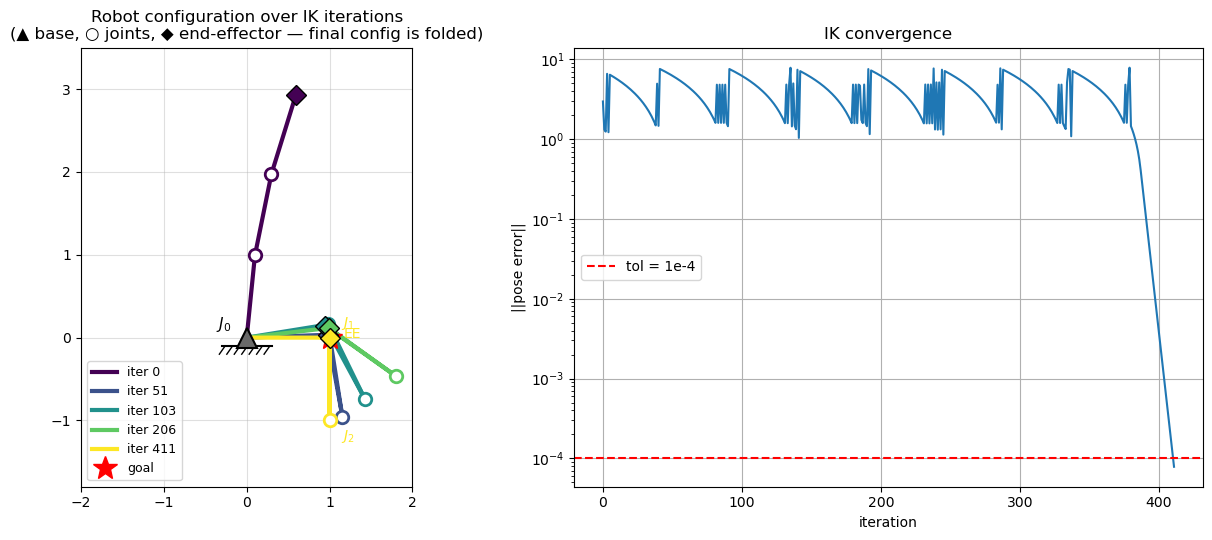

In [4]:
# Visualise convergence
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: snapshots of the robot configuration over time
ax = axes[0]
plot_base(ax, label='$J_0$')
n = len(hist)
snapshots = [0, n // 8, n // 4, n // 2, n - 1]
cmap = plt.cm.viridis
for i, k in enumerate(snapshots):
    plot_robot(ax, hist[k], color=cmap(i / (len(snapshots) - 1)),
               label=f'iter {k}',
               show_joint_labels=(i == len(snapshots) - 1))   # label only the final
ax.plot(*goal, 'r*', markersize=18, label='goal')
ax.set_aspect('equal'); ax.grid(True, alpha=0.4); ax.legend(loc='lower left', fontsize=9)
ax.set_xlim(-2, 2); ax.set_ylim(-1.8, 3.5)
ax.set_title('Robot configuration over IK iterations\n'
             '(▲ base, ○ joints, ◆ end-effector — final config is folded)')

# Right: convergence of pose error
ax = axes[1]
errs = [np.linalg.norm(np.array([goal[0], goal[1], 0.0]) - fk_pose(q)) for q in hist]
ax.semilogy(errs)
ax.axhline(1e-4, color='r', ls='--', label='tol = 1e-4')
ax.set_xlabel('iteration'); ax.set_ylabel('||pose error||')
ax.set_title('IK convergence'); ax.grid(True); ax.legend()

plt.tight_layout(); plt.show()

## 6. Null space and redundancy

So far the IK has been driving the full 3-vector pose $(x, y, \theta)$ — three constraints, three joints, no slack. But many practical tasks only constrain *part* of the pose. Most of the time you only care that the gripper reaches a point $(x^*, y^*)$ and the wrist angle $\theta$ is whatever falls out. With our 3-DOF arm, that's **2 task constraints, 3 joints — 1 degree of freedom of redundancy**. (Same structural setup as a 7-DOF arm reaching a 6-DOF pose: one extra joint with nothing to do.)

That extra DOF is what null spaces capture. Before getting to the robot, let's build the linear-algebra intuition on a tiny example.

### 6.1 What is a null space? (linear algebra primer)

A matrix $A$ takes a vector in and produces a vector out. The **null space** is just:

$$\mathcal{N}(A) = \{\,x \;:\; A\,x = 0\,\}$$

— *all the inputs that get mapped to zero*. It's a subspace of the input space.

**Why care?** Because non-zero vectors in the null space are "invisible" to $A$ — they don't show up in the output. Equivalently:

$$A\,x = A\,x' \iff x - x' \in \mathcal{N}(A)$$

So if the null space contains anything other than $\{0\}$, lots of different inputs produce the same output. The matrix is "losing information."

**Tiny example.** Take

$$A = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix}$$

This 2×3 matrix takes a 3-vector in and throws away the third coordinate. The null space is *the entire $x_3$-axis*: any vector $(0, 0, t)$ goes to zero. So $\dim \mathcal{N}(A) = 1$.

**Rank-nullity theorem** makes this systematic:

$$\dim \mathcal{N}(A) \;+\; \operatorname{rank}(A) \;=\; n \quad (\text{number of columns / input dimension})$$

For a "wide" matrix ($m < n$) with full row rank, $\dim \mathcal{N}(A) = n - m$. So a generic $2 \times 3$ matrix has a 1-D null space, a $3 \times 5$ matrix has a 2-D null space, and so on. *Wider matrices have larger null spaces — i.e., more "redundancy" in their inputs.*

In [5]:
# Toy example: a 2x3 matrix and its null space, computed via SVD.
# (The right-singular vectors corresponding to zero singular values span the null space.)
A = np.array([[1.0,  2.0, -1.0],
              [0.0,  1.0,  1.0]])

U, S, Vt = np.linalg.svd(A)
print(f'singular values        = {S}')
print(f'rank(A)                = {np.sum(S > 1e-10)}')
print(f'null-space dimension   = {3 - np.sum(S > 1e-10)}')

# When A is m x n with rank r, the last (n - r) rows of V^T span the null space.
null_basis = Vt[-1]
print(f'null-space basis vector = {null_basis}')
print(f'check: A @ null_basis  = {A @ null_basis}    (should be ~0)')

# Any input vector decomposes as: (component A cares about) + (null-space component).
# Adding the null-space component changes the input but not the output.
x  = np.array([1.0, 1.0, 1.0])
x2 = x + 0.7 * null_basis
print(f'\nA @ x                   = {A @ x}')
print(f'A @ (x + 0.7 * null_v)  = {A @ x2}    (identical)')

singular values        = [2.49721204 1.32813103]
rank(A)                = 2
null-space dimension   = 1
null-space basis vector = [ 0.90453403 -0.30151134  0.30151134]
check: A @ null_basis  = [4.99600361e-16 5.55111512e-17]    (should be ~0)

A @ x                   = [2. 2.]
A @ (x + 0.7 * null_v)  = [2. 2.]    (identical)


### 6.2 The Jacobian's null space — "useless" joint motions

Now back to the robot. The position Jacobian $J_{\text{pos}}(q)$ is the linear map from joint velocities to gripper velocities:

$$\dot p_{\text{gripper}} \;=\; J_{\text{pos}}(q) \, \dot q$$

Same shape as the toy matrix above — 3-D input ($\dot q$), 2-D output ($\dot p$) — so generically a 1-D null space. But now the null-space vector has a **physical meaning**:

> **The null space of $J_{\text{pos}}(q)$ is the set of joint velocities that produce *zero* gripper velocity.**

In other words: ways to wiggle the joints that *don't move the hand*.

**Physical picture.** Imagine the arm sitting in a configuration $q^*$ that puts the gripper at the target. Grab the gripper with one hand and hold it absolutely still. With your other hand, push the elbow sideways. Notice that **the elbow swings** — the shoulder, elbow, and wrist all rotate in a precisely coordinated way so that the gripper position stays exactly where you're holding it. That coordinated joint motion is the null-space direction $v$.

The continuous set of joint configurations reachable this way — all of them placing the gripper at the same $(x^*, y^*)$ — is called the **self-motion manifold**. For a 1-D redundant arm, it's a curve through $\mathbb{R}^3$ (joint space). The picture below traces a piece of it for our 3-link arm.

In [6]:
# Position-only task: target an (x*, y*) point, ignore wrist orientation.
def fk_xy(q):
    return fk_pose(q)[:2]                       # drop theta

def jacobian_xy(q):
    return jacobian_analytic(q)[:2, :]          # drop theta row -> 2x3

def ik_xy(q_start, target_xy, tol=1e-6, max_iter=500, alpha=0.5, max_step=0.3):
    q = np.array(q_start, dtype=float)
    for _ in range(max_iter):
        e = np.array(target_xy) - fk_xy(q)
        if np.linalg.norm(e) < tol: break
        if np.linalg.norm(e) > max_step:
            e = e * (max_step / np.linalg.norm(e))
        q = q + alpha * np.linalg.pinv(jacobian_xy(q)) @ e
    return q

# Pick a reachable target inside the workspace (radius < 3) and solve
target = np.array([1.5, 1.0])
q_star = ik_xy([0.3, 0.5, -0.2], target)
print(f'q*           = {q_star}')
print(f'fk_xy(q*)    = {fk_xy(q_star)}    (target was {target})')
print(f'position err = {np.linalg.norm(fk_xy(q_star) - target):.2e}')

# 2x3 position Jacobian at q*
J_pos = jacobian_xy(q_star)
print(f'\nJ_pos(q*) =\n{J_pos}')

# Null space: smallest singular value's right-singular vector
U, S, Vt = np.linalg.svd(J_pos)
print(f'\nsingular values = {S}')
v = Vt[-1]                                       # last row of V^T = null-space basis
print(f'null-space basis v = {v}')
print(f'sanity: ||J_pos @ v|| = {np.linalg.norm(J_pos @ v):.2e}   (should be ~0)')

q*           = [-2.46734772  1.88704955  0.24672839]
fk_xy(q*)    = [1.4999991 1.0000002]    (target was [1.5 1. ])
position err = 9.21e-07

J_pos(q*) =
[[-1.0000002  -1.78117876 -0.94487955]
 [ 1.4999991   0.87569144  0.32741812]]

singular values = [2.75697163 0.76716259]
null-space basis v = [ 0.11547399 -0.5153082   0.84918974]
sanity: ||J_pos @ v|| = 2.29e-16   (should be ~0)


### 6.3 Visualising the self-motion manifold

Below is the same target $(1.5, 1.0)$ as before. The 7 arm configurations all reach the **same gripper position** — only the elbow has swung. Each colored arm is a different point on the self-motion manifold; the black star is the target. This is what "1 DOF of redundancy" looks like physically: a continuous family of solutions, parameterised by a single "elbow angle" you're free to choose.

gripper position spread (should be ~0):  [0.0001409  0.00027765]


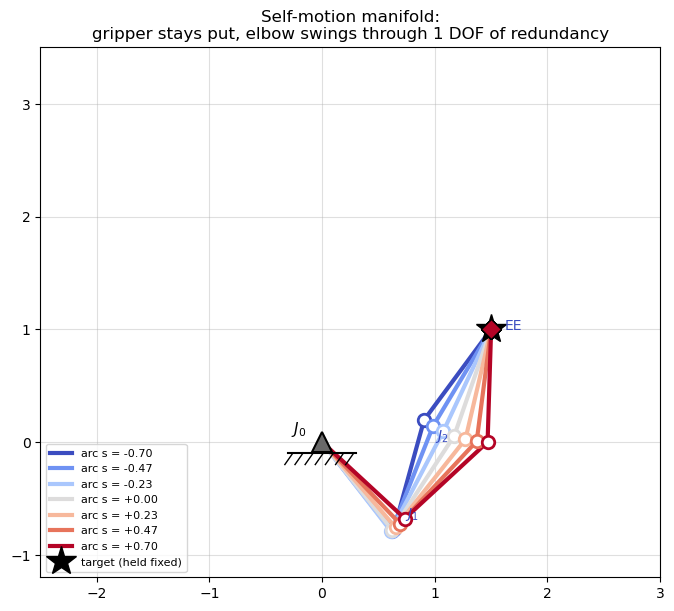

In [7]:
# Trace the self-motion manifold both forwards (+v) and backwards (-v) from q*.
def _flow(q0, xi, total_arc, n_steps):
    q = np.array(q0, dtype=float)
    dtau = total_arc / n_steps
    traj = [q.copy()]
    for _ in range(n_steps):
        J = jacobian_xy(q)
        N = np.eye(3) - np.linalg.pinv(J) @ J
        q = q + dtau * (N @ xi)
        traj.append(q.copy())
    return np.array(traj)

traj_fwd = _flow(q_star, xi=+v, total_arc=0.7, n_steps=300)
traj_bwd = _flow(q_star, xi=-v, total_arc=0.7, n_steps=300)
manifold = np.vstack([traj_bwd[::-1], traj_fwd])

fig, ax = plt.subplots(figsize=(8, 7.5))
plot_base(ax, label='$J_0$')
N = len(manifold)
snap_idx = [0, N//6, N//3, N//2, 2*N//3, 5*N//6, N-1]
cmap = plt.cm.coolwarm
for i, k in enumerate(snap_idx):
    s_signed = ((k - N//2) / (N//2)) * 0.7
    plot_robot(ax, manifold[k], color=cmap(i / (len(snap_idx) - 1)),
               label=f'arc s = {s_signed:+.2f}',
               show_joint_labels=(i == 0))   # label only one config to avoid clutter

ax.plot(*target, 'k*', markersize=22, label='target (held fixed)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.4); ax.legend(loc='lower left', fontsize=8)
ax.set_xlim(-2.5, 3); ax.set_ylim(-1.2, 3.5)
ax.set_title('Self-motion manifold:\n'
             'gripper stays put, elbow swings through 1 DOF of redundancy')

# Sanity check: gripper position is the same (to numerical precision) across the manifold
gripper_positions = np.array([fk_xy(q) for q in manifold])
print(f'gripper position spread (should be ~0):  {np.ptp(gripper_positions, axis=0)}')
plt.show()

### 6.4 The naive "just add the null-space vector" mistake

The null-space vector $v$ tells us the *instantaneous* direction in joint space that doesn't move the end-effector — at $q^*$. So if we want the elbow to swing by some amount $s$ along the self-motion manifold, the natural-but-wrong move is

$$q_{\text{new}} = q^* + s \cdot v$$

That works perfectly in the limit $s \to 0$, but for any *finite* $s$ the end-effector drifts. The reason: $J_{\text{pos}}(q)$ — and therefore its null space — *changes* as $q$ changes. The direction $v$ is only in the kernel at the single point $q^*$.

In [8]:
s = 0.5                                    # how far we want to move along the self-motion manifold
q_naive = q_star + s * v
print(f'q*           = {q_star}')
print(f'q* + s*v     = {q_naive}')
print(f'fk_xy(q*)    = {fk_xy(q_star)}')
print(f'fk_xy(naive) = {fk_xy(q_naive)}')
print(f'drift        = {np.linalg.norm(fk_xy(q_naive) - fk_xy(q_star)):.4f}   (should be 0 if v really stayed in the null space)')

q*           = [-2.46734772  1.88704955  0.24672839]
q* + s*v     = [-2.40961072  1.62939544  0.67132325]
fk_xy(q*)    = [1.4999991 1.0000002]
fk_xy(naive) = [1.48045461 0.96098799]
drift        = 0.0436   (should be 0 if v really stayed in the null space)


### 6.5 Doing it properly — integrate along the self-motion manifold

To follow the self-motion manifold for a *finite* arc length, we have to recompute the null space at every step. The continuous flow is

$$\dot q(\tau) = (I - J_{\text{pos}}^{+}\, J_{\text{pos}})\,\xi$$

where $\xi \in \mathbb{R}^3$ is whatever joint-velocity you'd *like* to apply, and the projector $(I - J_{\text{pos}}^{+}\, J_{\text{pos}})$ strips out the components that would move the end-effector. (The complementary projector $J_{\text{pos}}^{+}\, J_{\text{pos}}$ projects onto the row space of $J_{\text{pos}}$ — the joint motions that *do* move the end-effector.)

Discretising:

$$q_{k+1} = q_k + \Delta\tau \cdot (I - J_{\text{pos}}^{+}(q_k)\, J_{\text{pos}}(q_k))\,\xi_k$$

Take small enough steps and the end-effector stays on target throughout. To bias the self-motion in a particular direction (e.g., always pick the swing that increases elbow clearance), choose $\xi_k$ as the gradient of the objective you care about; the projector ensures the end-effector doesn't move regardless of what $\xi_k$ is.

In the demo below, $\xi$ is constant — the same direction $v$ we tried to add naively above. The integrated path tracks the self-motion manifold; the naive single jump leaves it.

q* + s*v (naive)         = [-2.40961072  1.62939544  0.67132325]
integrated final q       = [-2.37131257  1.61017413  0.64706814]
fk_xy(naive)             = [1.48045461 0.96098799]     drift = 4.3634e-02
fk_xy(integrated)        = [1.49990554 0.99983662]     drift = 1.8872e-04


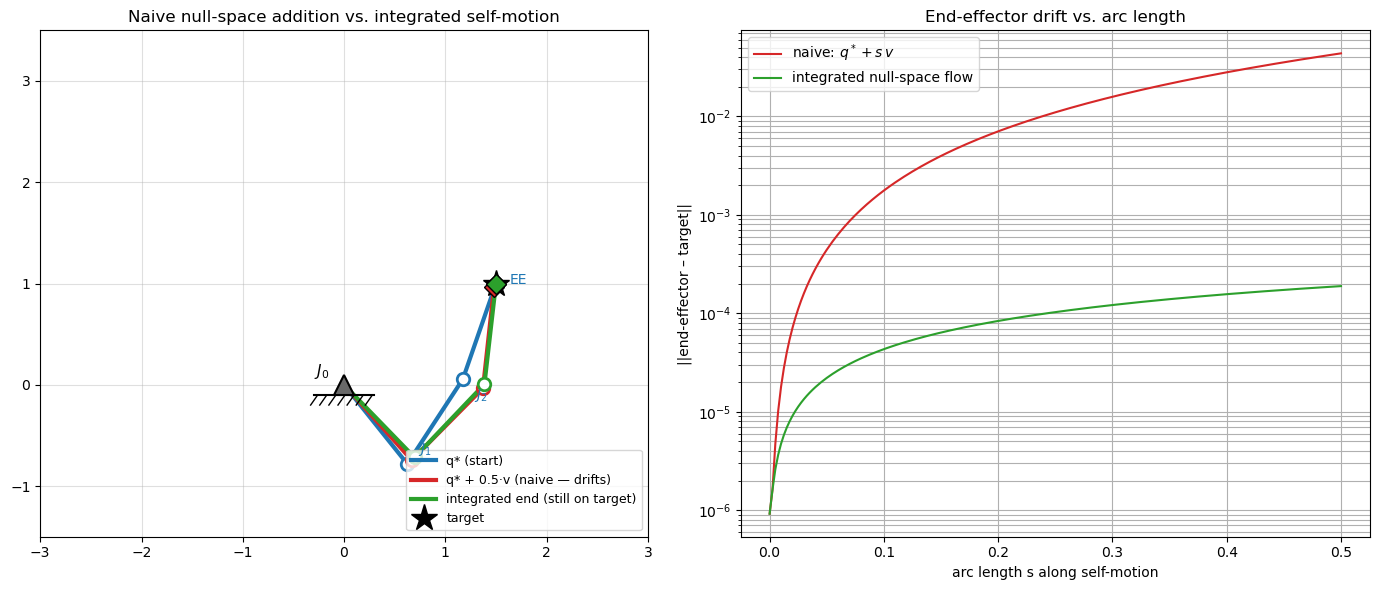

In [9]:
def integrate_self_motion(q0, xi, total_arc=0.5, n_steps=200):
    """Walk along the self-motion manifold by projecting xi into the null
    space of J_pos at every step. Returns trajectory of joint configs."""
    q = np.array(q0, dtype=float)
    dtau = total_arc / n_steps
    traj = [q.copy()]
    for _ in range(n_steps):
        J = jacobian_xy(q)
        N = np.eye(3) - np.linalg.pinv(J) @ J
        q = q + dtau * (N @ xi)
        traj.append(q.copy())
    return np.array(traj)

traj = integrate_self_motion(q_star, xi=v, total_arc=0.5, n_steps=200)
q_integrated = traj[-1]
print(f'q* + s*v (naive)         = {q_naive}')
print(f'integrated final q       = {q_integrated}')
print(f'fk_xy(naive)             = {fk_xy(q_naive)}     drift = {np.linalg.norm(fk_xy(q_naive) - target):.4e}')
print(f'fk_xy(integrated)        = {fk_xy(q_integrated)}     drift = {np.linalg.norm(fk_xy(q_integrated) - target):.4e}')

# Visualise: q*, q_naive, q_integrated
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
plot_base(ax, label='$J_0$')
plot_robot(ax, q_star,       color='C0', label='q* (start)',  show_joint_labels=True)
plot_robot(ax, q_naive,      color='C3', label='q* + 0.5·v (naive — drifts)')
plot_robot(ax, q_integrated, color='C2', label='integrated end (still on target)')
ax.plot(*target, 'k*', markersize=20, label='target')
ax.set_aspect('equal'); ax.grid(True, alpha=0.4); ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(-3, 3); ax.set_ylim(-1.5, 3.5)
ax.set_title('Naive null-space addition vs. integrated self-motion')

ax = axes[1]
ee_naive_per_step = []
ee_integ_per_step = []
for k in range(len(traj)):
    s_k = (k / (len(traj) - 1)) * 0.5
    ee_naive_per_step.append(np.linalg.norm(fk_xy(q_star + s_k * v) - target))
    ee_integ_per_step.append(np.linalg.norm(fk_xy(traj[k]) - target))
arc = np.linspace(0, 0.5, len(traj))
ax.semilogy(arc, ee_naive_per_step, 'C3', label='naive: $q^* + s\,v$')
ax.semilogy(arc, np.maximum(ee_integ_per_step, 1e-16), 'C2', label='integrated null-space flow')
ax.set_xlabel('arc length s along self-motion'); ax.set_ylabel('||end-effector – target||')
ax.set_title('End-effector drift vs. arc length'); ax.legend(); ax.grid(True, which='both')

plt.tight_layout(); plt.show()

### 6.6 Take-aways

**Take-aways**

- The **null space of $J$** is a *local linearisation*. It tells you the joint-velocity directions that produce zero end-effector velocity *at the current $q$*.
- Following that direction over a finite distance requires **integration**, not addition. Each step needs a freshly computed $J$ and null-space projector.
- The projector $(I - J^{+}\,J)$ is the workhorse of redundancy resolution — it lets you stack a "secondary" objective (avoid joint limits, maximise manipulability, dodge an obstacle) on top of the primary task without disturbing the primary task.
- This generalises directly: a 7-DOF arm doing 6-DOF pose tracking has a 1-D null space; same machinery, bigger matrices.

## 7. Mapping equations to source

| Concept | File | Symbol |
|---|---|---|
| Forward kinematics $T(q)$ | [`src/task.cpp`](../src/task.cpp) | `forward_kinematics` |
| Pose extraction $(x, y, \theta)$ | [`src/task.cpp`](../src/task.cpp) | `transformationMatrixToPose` |
| Jacobian $J(q)$ (numerical) | [`src/task.cpp`](../src/task.cpp) | `numericalDifferentiationFK`, `numericalDifferentiationFKFunctor` |
| Pseudo-inverse $J^{+}$ | [`src/task.cpp`](../src/task.cpp) | `pseudoInverse` |
| Damped Newton IK loop | [`src/task.cpp`](../src/task.cpp) | `inverse_kinematics` |
| Angle normalisation | [`src/task.cpp`](../src/task.cpp) | `normaliseAngle2` |
| Driver / example | [`src/main.cpp`](../src/main.cpp) | `main` |
| Tests | [`tests/src/kinematics_tests.cpp`](../tests/src/kinematics_tests.cpp) | `Kinematics.FK`, `Kinematics.IK` |

## 8. Possible extensions

- **Analytical Jacobian** instead of numerical (see §3) — cheaper and exact.
- **Damped least-squares** ($J^\top(JJ^\top + \lambda^2 I)^{-1}$) instead of plain $J^{+}$ — handles singularities more gracefully than SVD truncation.
- **Solution selection**: when multiple IK solutions exist, pick the one closest to the current configuration (minimise $\|q - q_{\text{start}}\|$).
- **Orientation control**: currently the test ignores $\theta$; the IK code drives all three pose components, but you can weight them or drop the $\theta$ row of $J$ to get pure positional IK with a redundant DOF.